In [42]:
import os

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn import preprocessing
from sklearn import metrics
from sklearn import pipeline
from sklearn import model_selection

import pickle

In [43]:
dataset_dir = "dataset"
models_dir = "models"

In [44]:
data_df = pd.read_csv(os.path.join(dataset_dir, "train_set.csv"))
X_train = data_df.drop(columns=["TARGET"])
y_train = data_df["TARGET"]

We have an imbalanced dataset.

In [45]:
n_neg, n_pos = np.bincount(y_train.astype(int))

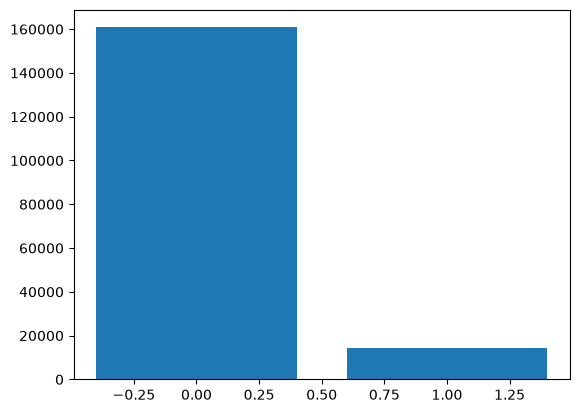

In [46]:
plt.bar([0, 1], [n_neg, n_pos])
plt.show()

We will inspect different models and evaluate them on the validation set.

In [6]:
val_results = {}

## Logistic regression

In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
params = {
    "lr__C": [10 ** i for i in range(-4, 1)]
}

In [71]:
lr_pipe = pipeline.Pipeline(steps=[
    ("scaler", preprocessing.StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced"))
])
grid = model_selection.GridSearchCV(estimator=lr_pipe, param_grid=params, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [72]:
val_results["lr_pipe"] = {
    "score": grid.best_score_,
    "params": grid.best_params_
}

In [73]:
val_results["lr_pipe"]

{'score': np.float64(0.7384451679845762), 'params': {'lr__C': 0.1}}

Saving the model.

In [74]:
model_path = os.path.join(models_dir, "lr_pipe.pkl")
with open(model_path, "wb") as file:
    pickle.dump(grid.best_estimator_, file)

## XGBoost

In [75]:
import xgboost

In [76]:
params = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 10]
}

In [77]:
xgb_clf = xgboost.XGBClassifier(scale_pos_weight=n_neg / n_pos)
grid = model_selection.GridSearchCV(estimator=xgb_clf, param_grid=params, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of info

In [78]:
val_results["xgb_clf"] = {
    "score": grid.best_score_,
    "params": grid.best_params_
}

In [79]:
val_results["xgb_clf"]

{'score': np.float64(0.7456551305322237),
 'params': {'max_depth': 3, 'n_estimators': 100}}

Saving the model.

In [80]:
model_path = os.path.join(models_dir, "xgb_clf.pkl")
with open(model_path, "wb") as file:
    pickle.dump(grid.best_estimator_, file)

## Fully-connected neural network

In [47]:
import copy
import itertools

import torch
import torch.nn as nn
from torch.nn import functional as F

In [48]:
BATCH_SIZE = 1024
NUM_EPOCHS = 50
PATIENCE = 5

In [58]:
params = {
    "hidden_dims": [
        (64,), (256,),
        (128, 64), (256, 128),
        (128, 64, 32), (256, 128, 64),
    ],
    "lr": [1e-4, 3e-4, 1e-3],
    "dropout": [0.1, 0.3]
}

In [50]:
X_train_t, X_val_t, y_train_t, y_val_t = model_selection.train_test_split(
    X_train,
    y_train,
    train_size=0.8,
    stratify=y_train,
    random_state=42
)

In [51]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train_t)
X_train_t = scaler.transform(X_train_t)
X_val_t = scaler.transform(X_val_t)

In [52]:
X_train_t = torch.tensor(X_train_t, dtype=torch.float32)
X_val_t = torch.tensor(X_val_t, dtype=torch.float32)
y_train_t = torch.tensor(y_train_t.values, dtype=torch.float32).reshape(-1, 1)
y_val_t = torch.tensor(y_val_t.values, dtype=torch.float32).reshape(-1, 1)


train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
val_dataset = torch.utils.data.TensorDataset(X_val_t, y_val_t)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [53]:
from model import NNBinaryClassifier

In [54]:
num_features = X_train_t.shape[1]

We have imbalanced data, so we compute weights that are used later for BCE loss.

In [55]:
pos_weight = torch.tensor([n_neg / n_pos])

In [56]:
def train_fcnn(hidden_dims, lr, dropout):
    fcnn = NNBinaryClassifier(in_features=num_features, hidden_dims=hidden_dims, dropout=dropout)

    optimizer = torch.optim.AdamW(fcnn.parameters(), lr=lr)
    
    stats = {
        "train_step": [],
        "train_loss": [],
        "train_roc_auc": [],
        "val_step": [],
        "val_loss": [],
        "val_roc_auc": []
    }

    best_state = None
    best_roc_auc = 0.0
    epochs_without_improvement = 0
    
    step = 0
    for epoch in range(NUM_EPOCHS):
        fcnn.train()
        for X_batch, y_batch in train_dataloader:
            y_logits = fcnn(X_batch)
    
            loss = F.binary_cross_entropy_with_logits(y_logits, y_batch, pos_weight=pos_weight)
            y_proba = torch.sigmoid(y_logits)
            y_pred = (y_proba > 0.5).to(dtype=torch.float32)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            stats["train_step"].append(step)
            stats["train_loss"].append(loss.item())
            stats["train_roc_auc"].append(metrics.roc_auc_score(y_batch, y_proba.detach().cpu().numpy()))
    
            step += 1
    
        fcnn.eval()
        with torch.no_grad():
            preds = []
            probas = []
            targets = []
            total_loss = 0.0
            num_instances = 0
            for X_batch, y_batch in val_dataloader:
                y_logits = fcnn(X_batch)
                y_proba = torch.sigmoid(y_logits)
                y_pred = (y_proba > 0.5).to(dtype=torch.float32)
    
                batch_size = X_batch.shape[0]
                total_loss += F.binary_cross_entropy_with_logits(y_logits, y_batch, pos_weight=pos_weight) * batch_size
                num_instances += batch_size

                probas.extend(y_proba)
                preds.extend(y_pred)
                targets.extend(y_batch.tolist())

            probas = np.array([s.item() for s in probas])
            preds = np.array([s.item() for s in preds])
            targets = np.array(targets).flatten()
            total_loss /= num_instances
            roc_auc = metrics.roc_auc_score(targets, probas)
                
            
            stats["val_step"].append(step)
            stats["val_loss"].append(total_loss)
            stats["val_roc_auc"].append(roc_auc)
    
            print(f"\tEPOCH: {epoch + 1}/{NUM_EPOCHS}: loss: {total_loss}; ROC AUC: {roc_auc}")

        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_state = copy.deepcopy(fcnn.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"\tEarly stopping after epoch {epoch + 1}")
                break

    fcnn.load_state_dict(best_state)
    return fcnn, best_roc_auc, stats

Searching for the best hyperparameters on the validation set. Each configuration is trained with early stopping and its best-epoch weights and ROC AUC are kept.

In [59]:
best_fcnn = None
best_stats = None
best_roc_auc = 0.0
best_params = None

for hidden_dims, lr, dropout in itertools.product(
    params["hidden_dims"], params["lr"], params["dropout"]
):
    print(f"HYPERPARAMETERS: hidden_dims: {hidden_dims}, lr: {lr}, dropout: {dropout}")
    fcnn, roc_auc, stats = train_fcnn(hidden_dims=hidden_dims, lr=lr, dropout=dropout)

    if roc_auc > best_roc_auc:
        best_fcnn = fcnn
        best_stats = stats
        best_roc_auc = roc_auc
        best_params = {
            "hidden_dims": hidden_dims,
            "lr": lr,
            "dropout": dropout
        }

HYPERPARAMETERS: hidden_dims: (64,), lr: 0.0001, dropout: 0.1
	EPOCH: 1/50: loss: 1.2257378101348877; ROC AUC: 0.6664198877698798
	EPOCH: 2/50: loss: 1.1893006563186646; ROC AUC: 0.6943724948751208
	EPOCH: 3/50: loss: 1.1664994955062866; ROC AUC: 0.7062430010054535
	EPOCH: 4/50: loss: 1.150794267654419; ROC AUC: 0.7150715460199097
	EPOCH: 5/50: loss: 1.139298439025879; ROC AUC: 0.721537944236377
	EPOCH: 6/50: loss: 1.1308835744857788; ROC AUC: 0.7265543628739426
	EPOCH: 7/50: loss: 1.1246585845947266; ROC AUC: 0.7302664236235972
	EPOCH: 8/50: loss: 1.1202545166015625; ROC AUC: 0.7326832223648807
	EPOCH: 9/50: loss: 1.1169975996017456; ROC AUC: 0.7345713429589169
	EPOCH: 10/50: loss: 1.115220069885254; ROC AUC: 0.7356815057352943
	EPOCH: 11/50: loss: 1.1140289306640625; ROC AUC: 0.7364563969108443
	EPOCH: 12/50: loss: 1.1132081747055054; ROC AUC: 0.7369485217793854
	EPOCH: 13/50: loss: 1.1129363775253296; ROC AUC: 0.7371878622436765
	EPOCH: 14/50: loss: 1.1127315759658813; ROC AUC: 0.73

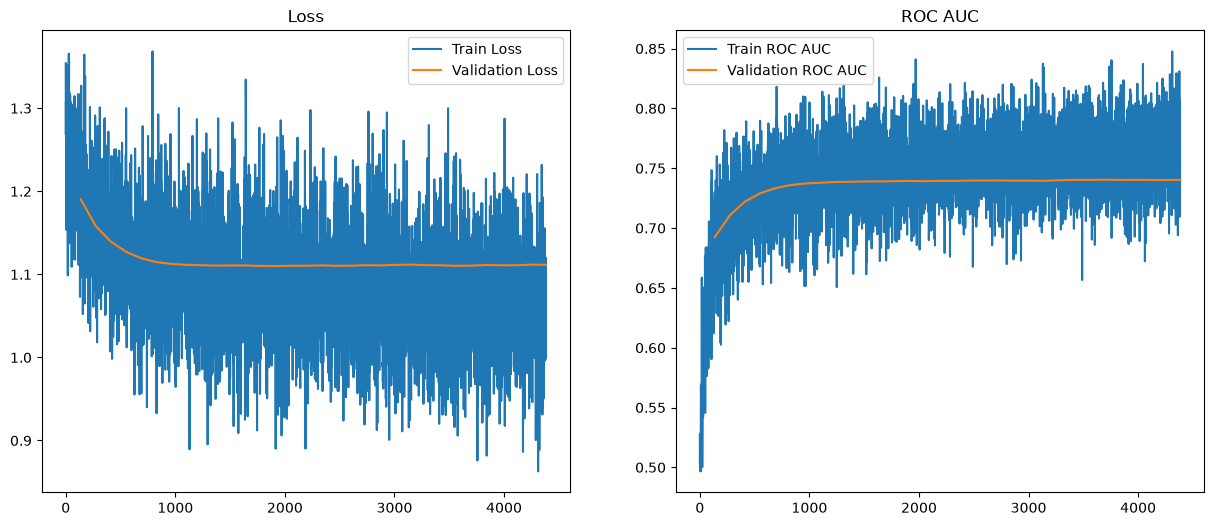

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(best_stats["train_step"], best_stats["train_loss"], label="Train Loss")
ax1.plot(best_stats["val_step"], best_stats["val_loss"], label="Validation Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(best_stats["train_step"], best_stats["train_roc_auc"], label="Train ROC AUC")
ax2.plot(best_stats["val_step"], best_stats["val_roc_auc"], label="Validation ROC AUC")
ax2.set_title("ROC AUC")
ax2.legend()

plt.show()

In [63]:
val_results["fcnn"] = {
    "score": best_roc_auc,
    "params": best_params
}

In [64]:
val_results["fcnn"]

{'score': 0.7404549860802376,
 'params': {'hidden_dims': (256,), 'lr': 0.0001, 'dropout': 0.3}}

Saving the model, its hyperparameters and the used scaler.

In [67]:
scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

In [68]:
model_path = os.path.join(models_dir, "fcnn.pt")
torch.save(best_fcnn.state_dict(), model_path)

params_path = os.path.join(models_dir, "fcnn_params.pkl")
with open(params_path, "wb") as f:
    pickle.dump(best_params, f)

Picking the best model on the validation set based on the ROC AUC score.

In [81]:
best_model = None
best_score = 0
for model, results in val_results.items():
    if results["score"] > best_score:
        best_score = results["score"]
        best_model = model

In [82]:
best_model

'xgb_clf'